## 🌾 Irrigation Need Prediction — Ensemble Blending Approach

This notebook explores a model ensembling strategy for predicting irrigation requirements using multiple high-performing submissions. Instead of relying on a single model, the approach focuses on combining diverse predictions to improve robustness and stability.

The workflow includes:

Merging predictions from multiple strong models
Analyzing agreement and disagreement patterns across models
Designing rule-based voting strategies
Visualizing inconsistencies using heatmaps
Generating a refined final prediction using ensemble logic

This method is particularly effective in tabular competitions where small improvements through blending can significantly impact leaderboard performance.

## 🙏 Credits & Inspiration

This work is inspired by the approach shared by nina2025.

## 🔰 Environment Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 📂 Data Sources

In [2]:
BASE_PATH = '/kaggle/input/competitions/playground-series-s6e4/'
EXT_PATH  = '/kaggle/input/datasets/nina2025/ps-s6e4-10/'

train_df = pd.read_csv(BASE_PATH + 'train.csv')
test_df  = pd.read_csv(BASE_PATH + 'test.csv')
sample   = pd.read_csv(BASE_PATH + 'sample_submission.csv')

## 🔎 Quick Dataset Exploration

In [3]:
print("Train:", train_df.shape)
print("Test :", test_df.shape)

display(train_df.head())

Train: (630000, 21)
Test : (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


## 📊 Target Distribution

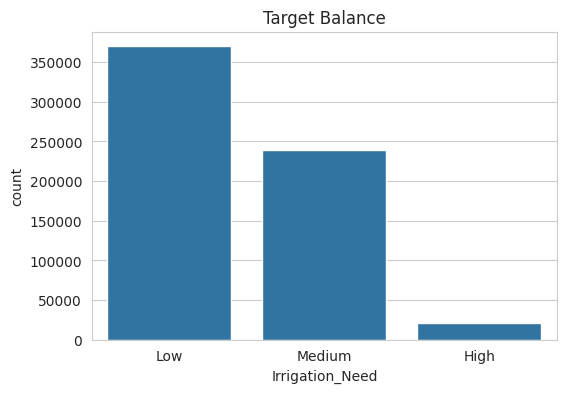

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x=train_df['Irrigation_Need'])
plt.title("Target Balance")
plt.show()

## 📉 Numerical Feature Overview

<Figure size 1000x600 with 0 Axes>

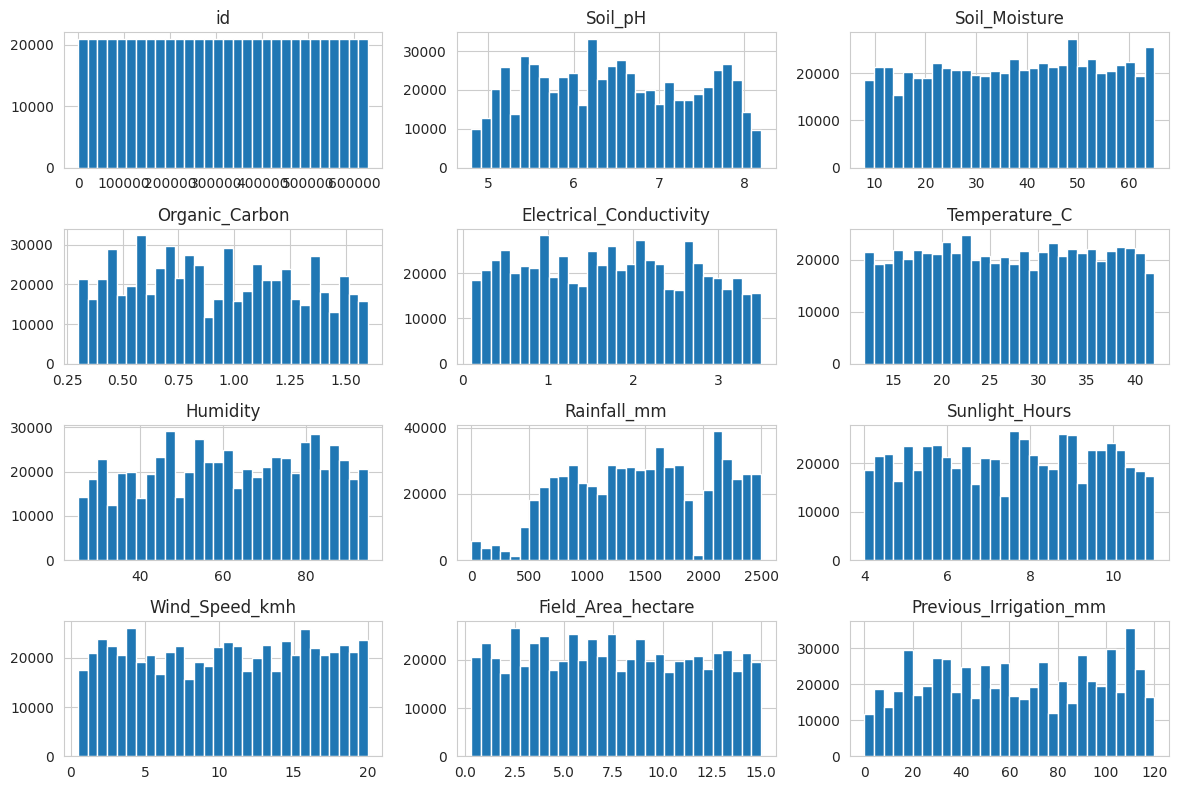

In [5]:
num_cols = train_df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10,6))
train_df[num_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

## 🔗 Submission Merge Utility

In [6]:
def combine_frames(frames):
    merged = frames[0]
    for f in frames[1:]:
        merged = merged.merge(f, on='id')
    return merged

## 🧠 Pattern Signature Builder

In [7]:
def signature_row(row, cols):
    tokens = []
    for c in cols:
        val = row[c]
        if val == 'Medium':
            tokens.append('_')
        elif val == 'Low':
            tokens.append('L')
        else:
            tokens.append('H')
    return " ".join(tokens)

## 🗳️ Voting Strategies (Core Logic Preserved)

In [8]:
def vote_strategy_A(row, cols):
    core = cols[:-1]
    fallback = cols[-1]
    
    if all(row[c] == row[core[0]] for c in core[:4]):
        return row[core[0]]
    return row[fallback]


def vote_strategy_B(row, cols):
    core = cols[:-1]
    fallback = cols[-1]
    
    if all(row[c] == row[core[0]] for c in core[:6]):
        return row[core[0]]
    return row[fallback]


def vote_strategy_C(row, cols):
    core = cols[:-1]
    fallback = cols[-1]
    
    if all(row[c] == row[core[0]] for c in core[:5]):
        return row[core[0]]
    return row[fallback]

## 🔍 Agreement Analysis (Visualization Layer)

In [9]:
def disagreement_map(df, cols, target_val):
    temp = df.copy()
    
    for c in cols:
        temp[c] = temp[c].apply(lambda x: np.nan if x == target_val else x)
    
    return temp[cols]


def plot_disagreement(df, cols):
    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    
    for i, val in enumerate(['Low', 'Medium', 'High']):
        sns.heatmap(
            disagreement_map(df, cols, val).isnull(),
            cbar=False,
            ax=axes[i]
        )
        axes[i].set_title(val)
    
    plt.tight_layout()
    plt.show()

## 📥 Load External Predictions

In [10]:
sub1 = pd.read_csv(EXT_PATH + '0.98011.csv').rename(columns={'Irrigation_Need':'m1'})
sub2 = pd.read_csv(EXT_PATH + '0.98011.a.csv').rename(columns={'Irrigation_Need':'m2'})
sub3 = pd.read_csv(EXT_PATH + '0.98011.b.csv').rename(columns={'Irrigation_Need':'m3'})
sub4 = pd.read_csv(EXT_PATH + '0.98011.c.csv').rename(columns={'Irrigation_Need':'m4'})
sub5 = pd.read_csv(EXT_PATH + '0.98026.csv').rename(columns={'Irrigation_Need':'m5'})

model_cols = ['m1','m2','m3','m4','m5']

## 🔗 Merge All Predictions

In [11]:
merged_preds = combine_frames([sub1, sub2, sub3, sub4, sub5])

## 🧬 Pattern Inspection

In [12]:
merged_preds['pattern'] = merged_preds.apply(lambda x: signature_row(x, model_cols), axis=1)

merged_preds['pattern'].value_counts().head()

pattern
L L L L L    159063
_ _ _ _ _     99603
H H H H H      9898
L L L L _       318
_ _ _ _ H       218
Name: count, dtype: int64

## 🔥 Visualizing Disagreements

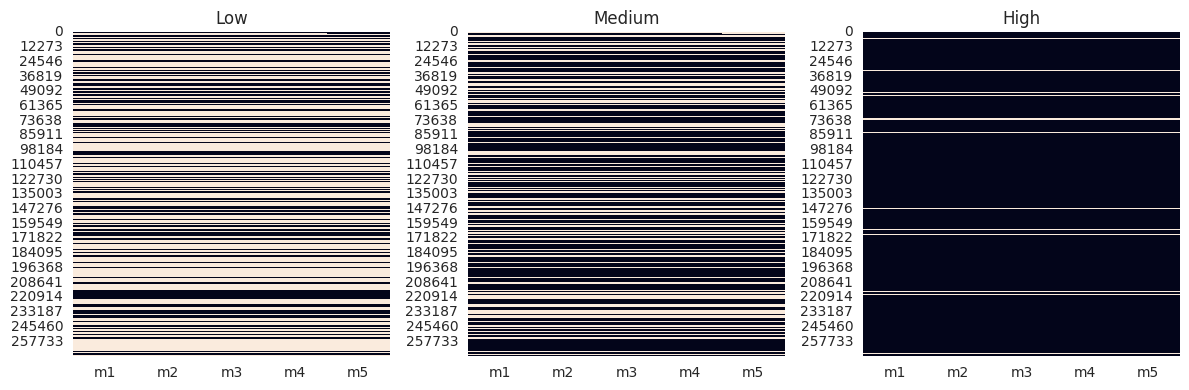

In [13]:
plot_disagreement(merged_preds, model_cols)

## 🧾 Final Voting

In [14]:
final_df = sample.copy()

final_df['Irrigation_Need'] = merged_preds.apply(
    lambda x: vote_strategy_A(x, model_cols), axis=1
)

## 📤 Submission Export

In [15]:
final_df.to_csv("submission.csv", index=False)
final_df.head()

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
